In [1]:
from torchvision import transforms
from torch.utils.data import Dataset
import os
from PIL import Image
from tqdm import tqdm

class SegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir, patch_size=512, overlap=0.5, transform=None):
        self.img_paths = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.lower().endswith('.jpg')])
        self.mask_paths = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.lower().endswith('.png')])
        self.patch_size = patch_size
        self.step = int(patch_size * (1 - overlap))
        self.transform = transform
        self.patches = self._extract_patches()

    def _extract_patches(self):
        patches = []
        for img_path, mask_path in zip(self.img_paths, self.mask_paths):
            img = Image.open(img_path)
            width, height = img.size
            width = int(width / 2)
            height = int(height /2)
            img = img.resize((width, height), Image.Resampling.LANCZOS)
            mask = Image.open(mask_path).convert('L')
            mask = mask.resize((width, height), Image.Resampling.LANCZOS)
            w, h = img.size
            for y in range(0, h - self.patch_size + 1, self.step):
                for x in range(0, w - self.patch_size + 1, self.step):
                    patches.append((img_path, mask_path, x, y))
        return patches

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        img_path, mask_path, x, y = self.patches[idx]
        img = Image.open(img_path).crop((x, y, x+self.patch_size, y+self.patch_size))
        mask = Image.open(mask_path).crop((x, y, x+self.patch_size, y+self.patch_size))
        if self.transform:
            img, mask = self.transform(img, mask)
        return img, mask


In [2]:
import torch
import numpy as np

class ToTensorAndEncode:
    def __init__(self, class_values):  # class_values: list of grayscale pixel values (e.g. [0, 85, 170])
        self.class_values = class_values
        self.img_tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __call__(self, img, mask):
        img_t = self.img_tf(img)
        mask_np = np.array(mask, dtype=np.uint8)

        label_map = np.zeros_like(mask_np, dtype=np.int64)
        for idx, value in enumerate(self.class_values):
            label_map[mask_np == value] = idx

        """one_hot = np.zeros((self.num_classes, *label_map.shape), dtype=np.float32)
        for c in range(self.num_classes):
            one_hot[c] = (label_map == c)"""
        mask_t = torch.from_numpy(label_map).long()

        return img_t, mask_t


In [3]:
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_classes, base_c=64):
        super().__init__()
        # Encoder
        self.down1 = DoubleConv(3, base_c)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(base_c, base_c*2)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = DoubleConv(base_c*2, base_c*4)
        self.pool3 = nn.MaxPool2d(2)
        self.down4 = DoubleConv(base_c*4, base_c*8)
        self.pool4 = nn.MaxPool2d(2)
        # Bottleneck
        self.bottleneck = DoubleConv(base_c*8, base_c*16)
        # Decoder
        self.up4 = nn.ConvTranspose2d(base_c*16, base_c*8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(base_c*16, base_c*8)
        self.up3 = nn.ConvTranspose2d(base_c*8, base_c*4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_c*8, base_c*4)
        self.up2 = nn.ConvTranspose2d(base_c*4, base_c*2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_c*4, base_c*2)
        self.up1 = nn.ConvTranspose2d(base_c*2, base_c, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_c*2, base_c)
        # Output
        self.outc = nn.Conv2d(base_c, n_classes, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)
        d2 = self.down2(p1)
        p2 = self.pool2(d2)
        d3 = self.down3(p2)
        p3 = self.pool3(d3)
        d4 = self.down4(p3)
        p4 = self.pool4(d4)

        bn = self.bottleneck(p4)

        u4 = self.up4(bn)
        c4 = self.dec4(torch.cat([u4, d4], dim=1))
        u3 = self.up3(c4)
        c3 = self.dec3(torch.cat([u3, d3], dim=1))
        u2 = self.up2(c3)
        c2 = self.dec2(torch.cat([u2, d2], dim=1))
        u1 = self.up1(c2)
        c1 = self.dec1(torch.cat([u1, d1], dim=1))

        return self.outc(c1)

In [4]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

augmentations = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
], additional_targets={'mask': 'mask'})

class AugmentedDataset(SegmentationDataset):
    def __getitem__(self, idx):
        img, mask = super().__getitem__(idx)
        augmented = augmentations(image=np.array(img), mask=np.array(mask))
        img_aug = Image.fromarray(augmented['image'])
        mask_aug = Image.fromarray(augmented['mask'])
        return self.transform(img_aug, mask_aug)


In [5]:
def get_num_classes(mask_dir):
    unique_values = set()
    for filename in tqdm(os.listdir(mask_dir)):
        mask = np.array(Image.open(os.path.join(mask_dir, filename)).convert('L'))
        unique_values.update(np.unique(mask))
    return len(unique_values), unique_values
mask_path = 'images/masks'
n_classes, class_values = get_num_classes(mask_path)
print(f"Detected {n_classes} unique classes: {class_values}")

100%|██████████| 9/9 [00:03<00:00,  2.64it/s]

Detected 3 unique classes: {0, 150, 255}


In [6]:
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F

# Hyperparameter
lr = 1e-4
epochs = 40
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Dataset & DataLoader
transform = ToTensorAndEncode(class_values=class_values)

train_ds = SegmentationDataset('images/imgs', 'images/masks', transform=transform)

val_ds   = SegmentationDataset('images/imgs',   'images/masks',   transform=transform)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)

val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=0)

# Modell, Optimizer, Scheduler
model = UNet(n_classes).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
best_iou = 0.0

def dice_coef(pred, target, eps=1e-6):
    # pred, target: one-hot [B, C, H, W]
    intersection = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    return ((2 * intersection + eps) / (union + eps)).mean()
def compute_class_weights(train_loader, n_classes):
    class_counts = [0] * n_classes
    for imgs, masks in tqdm(train_loader, desc="Counting class frequencies"):
        _, labels = masks.max(dim=1)  # Get the class labels from the masks
        for i in range(n_classes):
            class_counts[i] += (labels == i).sum().item()
    
    total_pixels = sum(class_counts)
    class_weights = [total_pixels / count if count != 0 else 1 for count in class_counts]
    class_weights = torch.tensor(class_weights).float().to(device)
    return class_weights

# Calculate class weights based on the training dataset
#class_weights = compute_class_weights(train_loader, n_classes)
class_weights = torch.tensor([1, 10, 100]).float().to(device)
print(class_weights)

tensor([  1.,  10., 100.], device='cuda:0')


In [8]:
import time
t0 = time.time()
checkpoint = 'best_unet.pth'
losses = []
val_losses = []
def weighted_cross_entropy_loss(logits, masks, class_weights):
    return F.cross_entropy(logits, masks, weight=class_weights)

if os.path.exists(checkpoint):
    print(f"Loading saved model from {checkpoint}")
    model.load_state_dict(torch.load(checkpoint))
    model.eval()
for epoch in range(epochs):
    model.train()
    train_loss = 0
    class_counts = [0] *n_classes
    for imgs, masks in tqdm(train_loader, desc=f"Train Ep {epoch}"):
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        loss = weighted_cross_entropy_loss(logits, masks, class_weights)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    losses.append(train_loss)
    # Validierung
    model.eval()
    val_loss, val_dice = 0, 0
    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f"Val"):
            imgs, masks = imgs.to(device), masks.to(device)

            logits = model(imgs)

            preds = F.softmax(logits, dim=1)
            val_loss += F.cross_entropy(logits, masks, weight=class_weights).item()
            pred_classes = preds.argmax(dim=1)
            for i in range(n_classes):
                class_counts[i] += (pred_classes == i).sum().item()
            masks_one_hot = F.one_hot(masks, num_classes=n_classes).permute(0, 3, 1, 2).float()
            val_dice += dice_coef(preds, masks_one_hot).item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    val_dice /= len(val_loader)
    scheduler.step(val_loss)
    print(f"Epoch {epoch} — Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")
    print("Class Detection Counts (Train):")
    for i, count in enumerate(class_counts):
        print(f"Class {i}: {count} pixels detected")
    # Modell speichern
    if val_dice > best_iou:
        best_iou = val_dice
        torch.save(model.state_dict(), checkpoint)

Loading saved model from best_unet.pth


Val: 100%|██████████| 315/315 [07:07<00:00,  1.36s/it]


Epoch 0 — Train Loss: 0.2996 | Val Loss: 0.4385 | Val Dice: 0.3121
Class Detection Counts (Train):
Class 0: 269214115 pixels detected
Class 1: 38672744 pixels detected
Class 2: 22414581 pixels detected


Val: 100%|██████████| 315/315 [07:53<00:00,  1.50s/it]


Epoch 1 — Train Loss: 0.3126 | Val Loss: 0.2069 | Val Dice: 0.3558
Class Detection Counts (Train):
Class 0: 310867441 pixels detected
Class 1: 18219911 pixels detected
Class 2: 1214088 pixels detected


...

Epoch 37 — Train Loss: 0.0666 | Val Loss: 0.0806 | Val Dice: 0.3926
Class Detection Counts (Train):
Class 0: 315693074 pixels detected
Class 1: 14158582 pixels detected
Class 2: 449784 pixels detected


Val: 100%|██████████| 315/315 [07:45<00:00,  1.48s/it]


Epoch 38 — Train Loss: 0.0684 | Val Loss: 0.0924 | Val Dice: 0.3924
Class Detection Counts (Train):
Class 0: 314438666 pixels detected
Class 1: 14705697 pixels detected
Class 2: 1157077 pixels detected


Val: 100%|██████████| 315/315 [07:23<00:00,  1.41s/it]

Epoch 39 — Train Loss: 0.0717 | Val Loss: 0.0637 | Val Dice: 0.3936
Class Detection Counts (Train):
Class 0: 313870083 pixels detected
Class 1: 15983865 pixels detected
Class 2: 447492 pixels detected


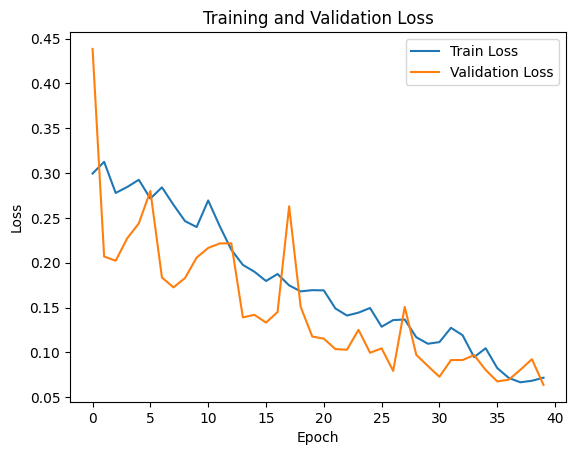

In [9]:
import matplotlib.pyplot as plt

plt.plot(range(epochs), losses, label='Train Loss')
plt.plot(range(epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [10]:
from torchvision import transforms
import torch
import torch.nn.functional as F
import numpy as np
import os 
from PIL import Image
def predict_img(net,
                full_img,
                device,
                out_threshold=0.5,
                class_values=None):
    """
    Predict the segmentation mask for a full PIL image using the given model.

    Args:
        net           : Trained segmentation model
        full_img      : PIL.Image input image (RGB)
        device        : torch.device
        out_threshold : Threshold for binary segmentation (ignored if multi-class)
        class_values  : Optional list of grayscale values for classes (for decoding)

    Returns:
        Numpy array of the predicted mask (HxW) as integers
    """
    net.eval()

    tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std= [0.229, 0.224, 0.225])
    ])

    img_tensor = tf(full_img).unsqueeze(0).to(device=device, dtype=torch.float32)

    with torch.no_grad():
        output = net(img_tensor)
        output = F.interpolate(output, size=full_img.size[::-1], mode='bilinear', align_corners=False)


        probs = F.softmax(output, dim=1)
        pred = torch.argmax(probs, dim=1).squeeze(0).cpu().numpy()
        if class_values:
            pred_mask = np.zeros_like(pred, dtype=np.uint8)
            for idx, val in enumerate(class_values):
                pred_mask[pred == idx] = val
            return pred_mask
        else:
            return pred.astype(np.uint8)



    return pred_mask
from PIL import Image
img = Image.open("images/imgs/DJI_1465.jpg").convert("RGB")
width, height = img.size
width = int(width / 2)
height = int(height /2)
img = img.resize((width, height), Image.Resampling.LANCZOS)
pred_mask = predict_img(
    net=model,
    full_img=img,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    class_values=[0, 150, 255]  # optional, if your classes use specific grayscale values
)
out_path="some_image_mask.jpg",
print(np.unique(pred_mask))
"""mask_img = Image.fromarray(pred_mask)
if pred_mask.ndim == 2:
    mask_img = mask_img.convert('L')
else:
    mask_img = mask_img.convert('RGB')

mask_img.save(out_path)"""

[  0 150 255]


"mask_img = Image.fromarray(pred_mask)\nif pred_mask.ndim == 2:\n    mask_img = mask_img.convert('L')\nelse:\n    mask_img = mask_img.convert('RGB')\n\nmask_img.save(out_path)"